### References

In [26]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/c4/0ab22726a04ede56f689476b760f98f8f46607caecff993017ac1b64aa5d/scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/a2/84/dc08d77fbf3d87d3ee27f6a0c6dcce1de5829a64f2eae85a0ecc1f0daa73/scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------------- ------------ 41.0/61.0 kB 326.8 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 372.4 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 325.1 kB/s eta 0:00:00
  Obtaining dependency information for 


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1. Análisis Exploratorio de Datos (EDA) con Pandas:

Carga un dataset de tu elección (por ejemplo, el dataset Iris). Realiza un análisis exploratorio básico incluyendo: visualización de las primeras y últimas filas, tipos de datos de las columnas, estadísticas descriptivas, y la presencia de valores nulos.

In [17]:
import pandas as pd

#df1 = pd.read_csv('student_dataset.csv')
df1 = pd.read_csv('movies.csv')

In [18]:
print("Primeras filas del DataFrame:")
print(df1.head(2))

print("\nÚltimas filas del DataFrame:")
print(df1.tail(2))

print("\nTipo de datos de cada columna:")
print(df1.dtypes)

print("\nEstadísticas descriptivas del DataFrame:")
print(df1.describe())

print("\nValores nulos en cada columna:")
print(df1.isnull().sum())

Primeras filas del DataFrame:
                      title  year  rating      votes  runtime certificate  \
0  The Shawshank Redemption  1994     9.3  3,168,010      142           R   
1             The Godfather  1972     9.2  2,212,884      175           R   

          genre gross_total  
0         Drama     $29.33M  
1  Crime, Drama    $250.93M  

Últimas filas del DataFrame:
                  title  year  rating    votes  runtime certificate  \
248  Gangs of Wasseypur  2012     8.2  113,517      321     Unrated   
249         Höstsonaten  1978     8.1   41,972       99          PG   

                     genre gross_total  
248  Action, Comedy, Crime      $4.38M  
249           Drama, Music      $0.04M  

Tipo de datos de cada columna:
title              str
year             int64
rating         float64
votes              str
runtime          int64
certificate        str
genre              str
gross_total        str
dtype: object

Estadísticas descriptivas del DataFrame:
         

### 2. Limpieza y Preparación de Datos:
A partir del mismo dataset, identifica y trata los valores nulos, ya sea eliminándolos o imputándolos. Convierte las variables categóricas a numéricas utilizando técnicas de codificación.

In [20]:
import pandas as pd

# Valores nulos
print("Nulos por columna:")
print(df1.isnull().sum())
print(f"\nTotal de nulos en el dataset: {df1.isnull().sum().sum()}")

# Tratamiento de nulos por imputación
df_limpio = df1.copy()

# Columnas numéricas: imputar con mediana
num_cols = df_limpio.select_dtypes(include="number").columns
for col in num_cols:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

# Columnas categóricas: imputar con moda
cat_cols = df_limpio.select_dtypes(exclude="number").columns
for col in cat_cols:
    if df_limpio[col].mode().empty:
        df_limpio[col] = df_limpio[col].fillna("Desconocido")
    else:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mode()[0])

print("\nNulos por columna (después de imputar):")
print(df_limpio.isnull().sum())

# Codificación de variables categóricas
df_codificado = pd.get_dummies(df_limpio, columns=cat_cols, drop_first=True, dtype=int)

print("\nForma original:", df1.shape)
print("Forma después de codificar:", df_codificado.shape)


Nulos por columna:
title          0
year           0
rating         0
votes          0
runtime        0
certificate    0
genre          0
gross_total    4
dtype: int64

Total de nulos en el dataset: 4

Nulos por columna (después de imputar):
title          0
year           0
rating         0
votes          0
runtime        0
certificate    0
genre          0
gross_total    0
dtype: int64

Forma original: (250, 8)
Forma después de codificar: (250, 837)


### 3. Aplicación de K-Means:
Utiliza el algoritmo K-Means para agrupar los datos del dataset Iris basándote en sus características. Define el número de clusters y visualiza los clusters resultantes.

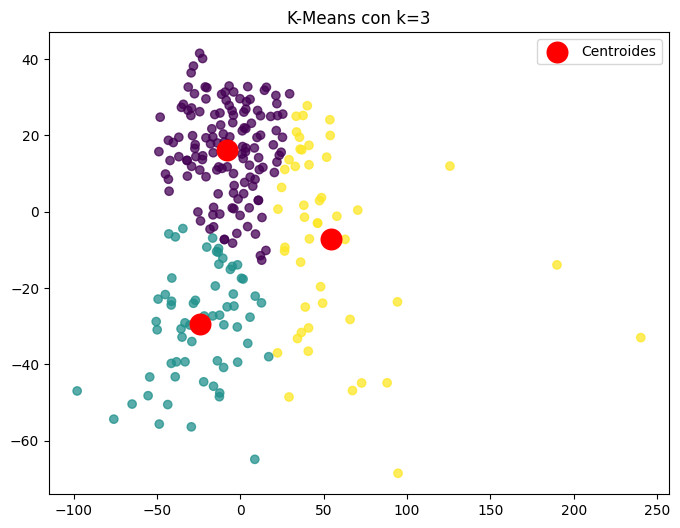

Datos utilizados para clustering: (250, 837)
Distribución de elementos por cluster:
0    138
1     64
2     48
Name: count, dtype: int64


In [33]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Usamos solo columnas numéricas para clustering
X = df_codificado.select_dtypes(include="number")

# Número de clusters definido
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

# Convertimos centroides a DataFrame con las mismas columnas
centros_df = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
centros_2d = pca.transform(centros_df)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", alpha=0.75)
plt.scatter(centros_2d[:, 0], centros_2d[:, 1], c="red", marker="o", s=220, label="Centroides")
plt.title(f"K-Means con k={k}")
plt.legend()
plt.show()

print(f"Datos utilizados para clustering: {X.shape}")
print("Distribución de elementos por cluster:")
print(pd.Series(clusters).value_counts().sort_index())


### 4. Comparación de Algoritmos de Clustering:
Aplica al menos dos algoritmos de clustering distintos (por ejemplo, K-Means y GMM) al mismo dataset. Compara los resultados de los diferentes algoritmos utilizando métricas y visualiza los clusters formados. 

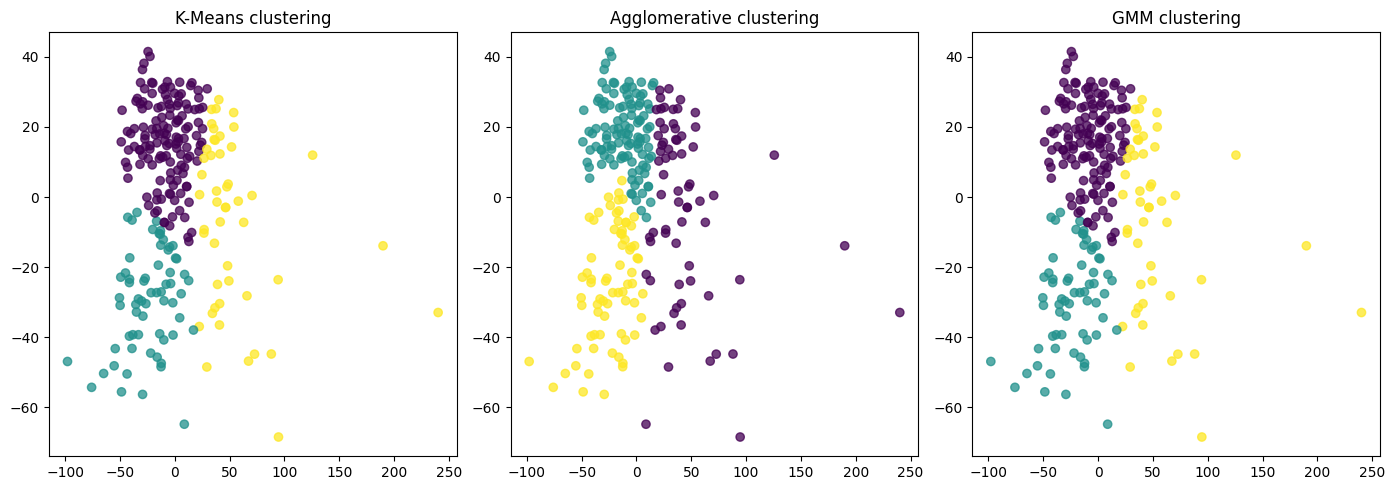

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Matriz numérica para clustering
X = df_codificado.select_dtypes(include="number")
k = 3

# Modelos
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
gmm = GaussianMixture(n_components=k, random_state=42)

# Etiquetas por modelo
labels_kmeans = kmeans.fit_predict(X)
labels_agg = agg.fit_predict(X)
labels_gmm = gmm.fit_predict(X)

# Proyección a 2D para visualizar los clusters
pca_comp = PCA(n_components=2, random_state=42)
X_2d_comp = pca_comp.fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].scatter(X_2d_comp[:, 0], X_2d_comp[:, 1], c=labels_kmeans, cmap="viridis", alpha=0.75)
axes[0].set_title("K-Means clustering")

axes[1].scatter(X_2d_comp[:, 0], X_2d_comp[:, 1], c=labels_agg, cmap="viridis", alpha=0.75)
axes[1].set_title("Agglomerative clustering")
    
axes[2].scatter(X_2d_comp[:, 0], X_2d_comp[:, 1], c=labels_gmm, cmap="viridis", alpha=0.75)
axes[2].set_title("GMM clustering")

plt.tight_layout()
plt.show()